## 1. Setup e Importações

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
sns.set_theme(style="ticks", palette="muted")
plt.rcParams['figure.figsize'] = (10, 5)

## 2. Carregamento e Inspeção dos Dados

In [2]:
df = pd.read_excel('customer_churn_records.xlsx')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [3]:
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}")
df.dtypes

Linhas: 10000 | Colunas: 18


RowNumber               int64
CustomerId              int64
Surname                   str
CreditScore             int64
Geography                 str
Gender                    str
Age                     int64
Tenure                  int64
Balance               float64
NumOfProducts           int64
HasCrCard               int64
IsActiveMember          int64
EstimatedSalary       float64
Exited                  int64
Complain                int64
Satisfaction Score      int64
Card Type                 str
Point Earned            int64
dtype: object

In [4]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [5]:
df.isnull().sum()

RowNumber             0
CustomerId            0
Surname               0
CreditScore           0
Geography             0
Gender                0
Age                   0
Tenure                0
Balance               0
NumOfProducts         0
HasCrCard             0
IsActiveMember        0
EstimatedSalary       0
Exited                0
Complain              0
Satisfaction Score    0
Card Type             0
Point Earned          0
dtype: int64

In [6]:
taxa_churn = df['Exited'].mean() * 100
print(f"Taxa de Churn: {taxa_churn:.2f}%")

Taxa de Churn: 20.38%


💡 **Dicionário de variáveis relevantes:**

| Coluna | Descrição |
|--------|-----------|
| `CreditScore` | Pontuação de crédito |
| `Geography` | País de residência |
| `Gender` | Gênero |
| `Age` | Idade |
| `Tenure` | Anos como cliente |
| `Balance` | Saldo médio |
| `NumOfProducts` | Nº de produtos contratados |
| `HasCrCard` | Possui cartão de crédito |
| `IsActiveMember` | Acessou a conta nos últimos 30 dias |
| `EstimatedSalary` | Salário estimado |
| `Exited` | Cancelou conta (1=Sim, 0=Não) |
| `Complain` | Fez reclamação (1=Sim, 0=Não) |
| `SatisfactionScore` | Nível de satisfação (1 a 5) |
| `CardType` | Tipo de cartão (DIAMOND, GOLD, etc.) |
| `PointEarned` | Pontos no programa de fidelidade |

## 3. Limpeza e Pré-processamento

In [7]:
# Remover identificadores e duplicatas
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], errors="ignore")

print(f"Duplicatas: {df.duplicated().sum()}")
df = df.drop_duplicates()

Duplicatas: 0


In [8]:
# Padronizar nomes de colunas com espaço
df = df.rename(columns={
    'Satisfaction Score': 'SatisfactionScore',
    'Card Type':          'CardType',
    'Point Earned':       'PointEarned'
})

In [9]:
# Encoding de variáveis categóricas
encoders = {}

for col in ['Geography', 'Gender', 'CardType']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,SatisfactionScore,CardType,PointEarned
0,619,0,0,42,2,0.00,1,1,1,101348.88,1,1,2,0,464
1,608,2,0,41,1,83807.86,1,0,1,112542.58,0,1,3,0,456
2,502,0,0,42,8,159660.80,3,1,0,113931.57,1,1,3,0,377
3,699,0,0,39,1,0.00,2,0,0,93826.63,0,0,5,1,350
4,850,2,0,43,2,125510.82,1,1,1,79084.10,0,0,5,1,425


In [10]:
# Variável alvo: 1 = cancelou, 0 = permaneceu
TARGET = 'Exited'

## 4. Bins — Faixas das Variáveis Numéricas (pd.qcut)

In [11]:
bins_config = {
    'CreditScore':     5,
    'Age':             4,
    'Tenure':          4,
    'Balance':         4,
    'EstimatedSalary': 4,
    'PointEarned':     5
}

for feat, q in bins_config.items():
    df[f'{feat}_bin'] = pd.qcut(df[feat], q=q, duplicates='drop')

# distribuição da faixa de pontos
df['PointEarned_bin'].value_counts().sort_index()

PointEarned_bin
(118.999, 370.0]    2006
(370.0, 529.0]      2006
(529.0, 682.0]      1997
(682.0, 840.0]      1992
(840.0, 1000.0]     1999
Name: count, dtype: int64

In [12]:
# Taxa de churn por faixa de cada variável
for col_bin in [c for c in df.columns if c.endswith('_bin')]:
    taxa = df.groupby(col_bin)[TARGET].mean() * 100
    print(f"\n{col_bin}:")
    print(taxa.round(1).to_string())


CreditScore_bin:
CreditScore_bin
(349.999, 566.0]    22.5
(566.0, 627.0]      20.8
(627.0, 678.0]      19.7
(678.0, 735.0]      18.3
(735.0, 850.0]      20.6

Age_bin:
Age_bin
(17.999, 32.0]     7.6
(32.0, 37.0]      10.8
(37.0, 44.0]      20.7
(44.0, 92.0]      44.6

Tenure_bin:
Tenure_bin
(-0.001, 3.0]    21.1
(3.0, 5.0]       20.6
(5.0, 7.0]       18.7
(7.0, 10.0]      20.5

Balance_bin:
Balance_bin
(-0.001, 97198.54]        15.8
(97198.54, 127644.24]     26.3
(127644.24, 250898.09]    23.7

EstimatedSalary_bin:
EstimatedSalary_bin
(11.579, 51002.11]          20.0
(51002.11, 100193.915]      19.8
(100193.915, 149388.248]    20.1
(149388.248, 199992.48]     21.6

PointEarned_bin:
PointEarned_bin
(118.999, 370.0]    21.2
(370.0, 529.0]      19.0
(529.0, 682.0]      20.7
(682.0, 840.0]      22.0
(840.0, 1000.0]     18.9


## 5. Weight of Evidence (WoE) e Information Value (IV)

In [13]:
def calc_woe_iv(df, feature, target='Exited'):
    total_events     = df[target].sum()
    total_non_events = (df[target] == 0).sum()

    grouped = df.groupby(feature)[target].agg(
        events='sum',
        non_events=lambda x: (x == 0).sum()
    ).reset_index()

    grouped['dist_events']     = (grouped['events']     / total_events).replace(0, 0.0001)
    grouped['dist_non_events'] = (grouped['non_events'] / total_non_events).replace(0, 0.0001)

    grouped['WoE'] = np.log(grouped['dist_events'] / grouped['dist_non_events'])
    grouped['IV']  = (grouped['dist_events'] - grouped['dist_non_events']) * grouped['WoE']

    return grouped, grouped['IV'].sum()

In [14]:
# Variáveis com bin + categóricas originais
vars_woe = {
    'CreditScore_bin':     'CreditScore',
    'Age_bin':             'Age',
    'Tenure_bin':          'Tenure',
    'Balance_bin':         'Balance',
    'EstimatedSalary_bin': 'EstimatedSalary',
    'PointEarned_bin':     'PointEarned',
    'Geography':           'Geography',
    'Gender':              'Gender',
    'HasCrCard':           'HasCrCard',
    'IsActiveMember':      'IsActiveMember',
    'CardType':            'CardType',
    'Complain':            'Complain',
    'NumOfProducts':       'NumOfProducts',
    'SatisfactionScore':   'SatisfactionScore'
}

iv_results = {
    nome: round(calc_woe_iv(df, col)[1], 4)
    for col, nome in vars_woe.items()
}

iv_df = (
    pd.DataFrame.from_dict(iv_results, orient='index', columns=['IV'])
    .sort_values('IV', ascending=False)
)
print(iv_df.to_string())

                        IV
Complain           12.8685
NumOfProducts       0.9689
Age                 0.7490
Geography           0.1680
IsActiveMember      0.1536
Balance             0.0841
Gender              0.0694
CreditScore         0.0072
PointEarned         0.0059
CardType            0.0031
Tenure              0.0030
SatisfactionScore   0.0023
EstimatedSalary     0.0019
HasCrCard           0.0003


## 6. Análise de Correlação

In [15]:
# Selecionar variáveis com IV >= 0.05, excluindo Complain
vars_relevantes = [
    col for col in iv_df[iv_df['IV'] >= 0.05].index
    if col != 'Complain'
]

print("Variáveis selecionadas:", vars_relevantes)

Variáveis selecionadas: ['NumOfProducts', 'Age', 'Geography', 'IsActiveMember', 'Balance', 'Gender']


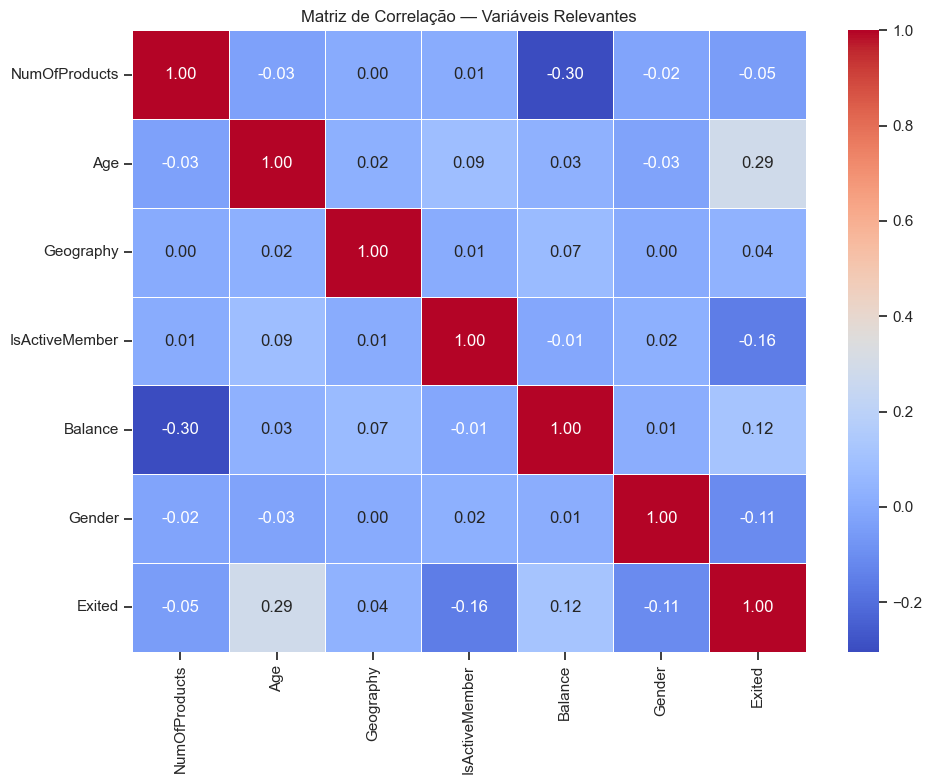

In [16]:
# Matriz de correlação entre variáveis relevantes
corr_cols = [v for v in vars_relevantes if v in df.columns] + [TARGET]

plt.figure(figsize=(10, 8))
sns.heatmap(
    df[corr_cols].corr(),
    annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5
)
plt.title('Matriz de Correlação — Variáveis Relevantes')
plt.tight_layout()
plt.show()

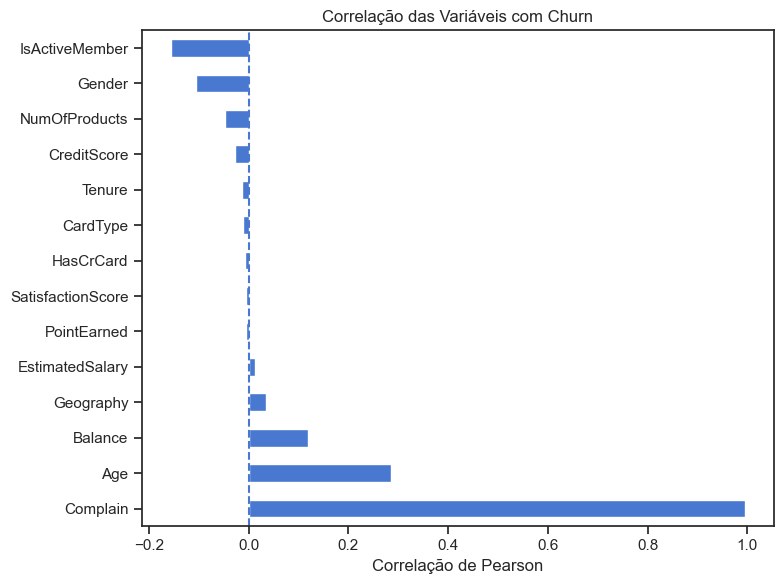

In [17]:
# Correlação de cada variável com o target (sem colunas de bin)
bin_cols = [c for c in df.columns if c.endswith('_bin')]

corr_target = (
    df.drop(columns=bin_cols, errors='ignore')
      .corr(numeric_only=True)[[TARGET]]
      .drop(index=TARGET, errors='ignore')
      .sort_values(TARGET, ascending=False)
)

corr_target.plot(kind='barh', figsize=(8, 6), legend=False)
plt.axvline(0, linestyle='--')
plt.title('Correlação das Variáveis com Churn')
plt.xlabel('Correlação de Pearson')
plt.tight_layout()
plt.show()

## 7. Resumo Estatístico por Grupo (Ativo vs Cancelado)

In [18]:
VARIAVEIS_ANALISE = ['Age', 'Balance', 'NumOfProducts']

def resumo_estatistico(df_subset, nome_grupo, target=TARGET):
    ativos     = df[df[target] == 0]
    cancelados = df[df[target] == 1]

    resultados = []
    for col in VARIAVEIS_ANALISE:
        media           = df_subset[col].mean()
        mediana         = df_subset[col].median()
        media_ativos    = ativos[col].mean()
        media_cancelados = cancelados[col].mean()
        diff_rel        = ((media_ativos / media_cancelados) - 1) * 100
        desvio          = df_subset[col].std()
        coef_var        = (desvio / media) * 100 if media != 0 else np.nan
        assimetria      = df_subset[col].skew()

        resultados.append({
            'Variável':                col,
            'Média':                   round(media, 2),
            'Mediana':                 round(mediana, 2),
            'Diferença Relativa':      f'{diff_rel:.1f}%',
            'Desv Padrão':             round(desvio, 2),
            'Coeficiente de Variação': f'{coef_var:.0f}%',
            'Assimetria':              round(assimetria, 4)
        })

    tabela = pd.DataFrame(resultados)
    print(f'\n{nome_grupo}')
    display(tabela)
    return tabela

ativos     = df[df[TARGET] == 0]
cancelados = df[df[TARGET] == 1]

resumo_estatistico(ativos, 'Ativos')
resumo_estatistico(cancelados, 'Cancelados')


Ativos


,Variável,Média,Mediana,Diferença Relativa,Desv Padrão,Coeficiente de Variação,Assimetria
0,Age,37.41,36.00,-16.6%,10.13,27%,1.3777
1,Balance,72742.75,92063.06,-20.2%,62851.58,86%,-0.0468
2,NumOfProducts,1.54,2.00,4.7%,0.51,33%,-0.0464



Cancelados


,Variável,Média,Mediana,Diferença Relativa,Desv Padrão,Coeficiente de Variação,Assimetria
0,Age,44.84,45.00,-16.6%,9.76,22%,0.0787
1,Balance,91109.48,109344.23,-20.2%,58346.48,64%,-0.5129
2,NumOfProducts,1.48,1.00,4.7%,0.80,54%,1.5694


,Variável,Média,Mediana,Diferença Relativa,Desv Padrão,Coeficiente de Variação,Assimetria
0,Age,44.84,45.00,-16.6%,9.76,22%,0.0787
1,Balance,91109.48,109344.23,-20.2%,58346.48,64%,-0.5129
2,NumOfProducts,1.48,1.00,4.7%,0.80,54%,1.5694


## 8. Distribuição de Churn por Variável

In [19]:
def plot_churn_distribution(df, coluna, target=TARGET, xlabel=None, figsize=(8, 6)):
    stats = (
        df.groupby(coluna)[target]
          .agg(total_clientes='count', cancelados='sum')
          .sort_index()
    )
    stats['ativos']        = stats['total_clientes'] - stats['cancelados']
    stats['pct_cancelados'] = stats['cancelados'] / stats['total_clientes'] * 100

    fig, ax1 = plt.subplots(figsize=figsize)
    x     = range(len(stats))
    width = 0.4
    label = xlabel or coluna

    ax1.bar([i - width/2 for i in x], stats['ativos'],     width=width, label='Ativos')
    ax1.bar([i + width/2 for i in x], stats['cancelados'], width=width, label='Cancelados')
    ax1.set_xlabel(label)
    ax1.set_ylabel('Quantidade de Clientes')
    ax1.set_title(f'Distribuição por {label}: Ativos, Cancelados e % Churn')
    ax1.set_xticks(list(x))
    ax1.set_xticklabels(stats.index.astype(str), rotation=45)
    ax1.legend(loc='upper left')

    ax2 = ax1.twinx()
    ax2.plot(x, stats['pct_cancelados'], marker='o', linewidth=2, color='red', label='% Cancelados')
    ax2.set_ylabel('% Cancelados')
    ax2.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

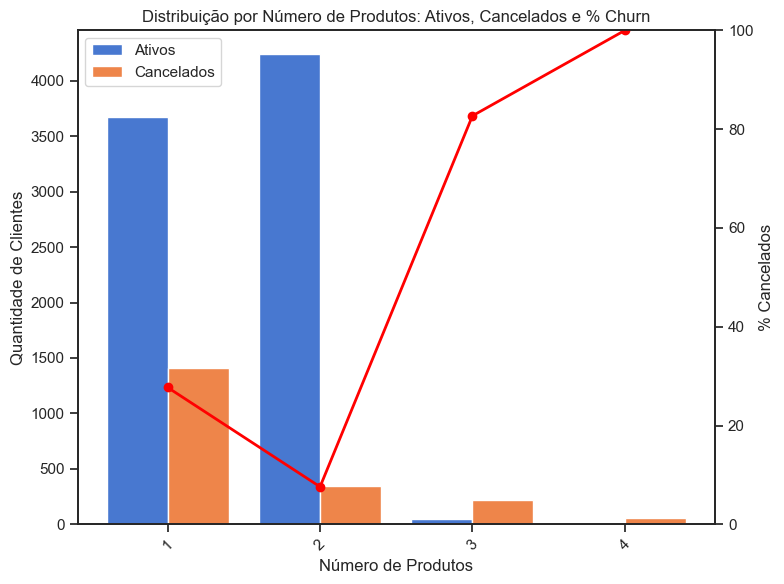

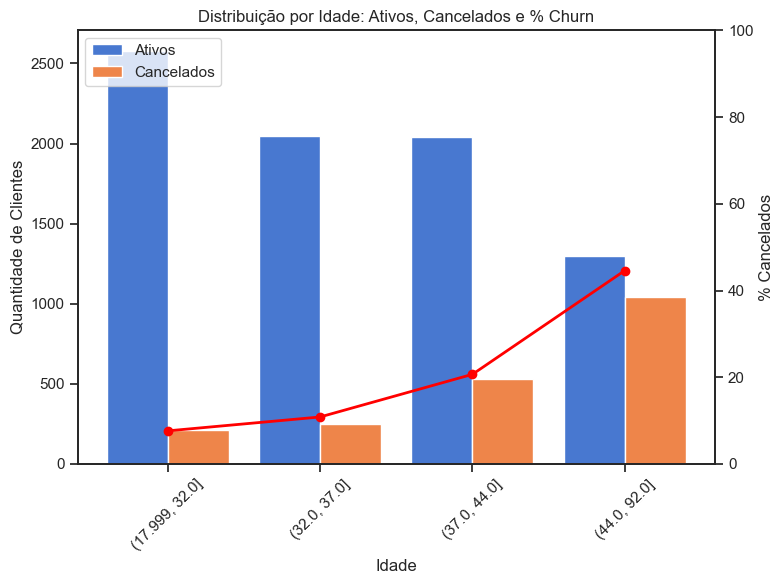

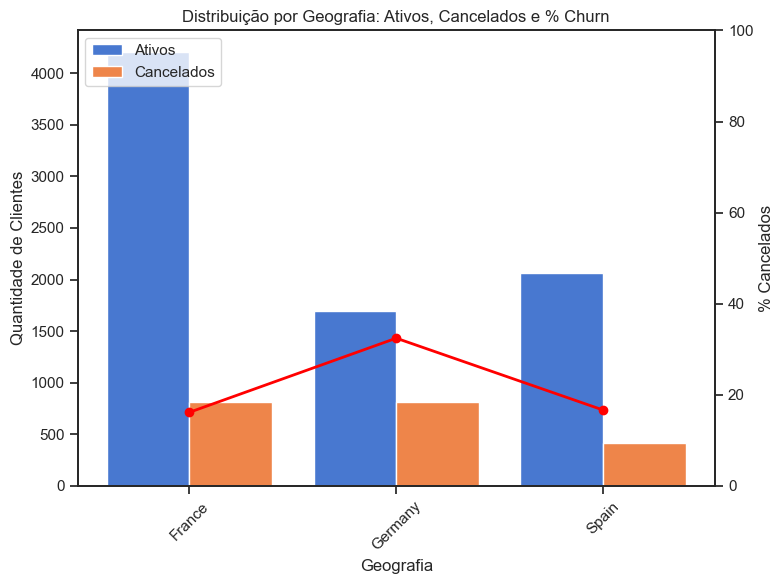

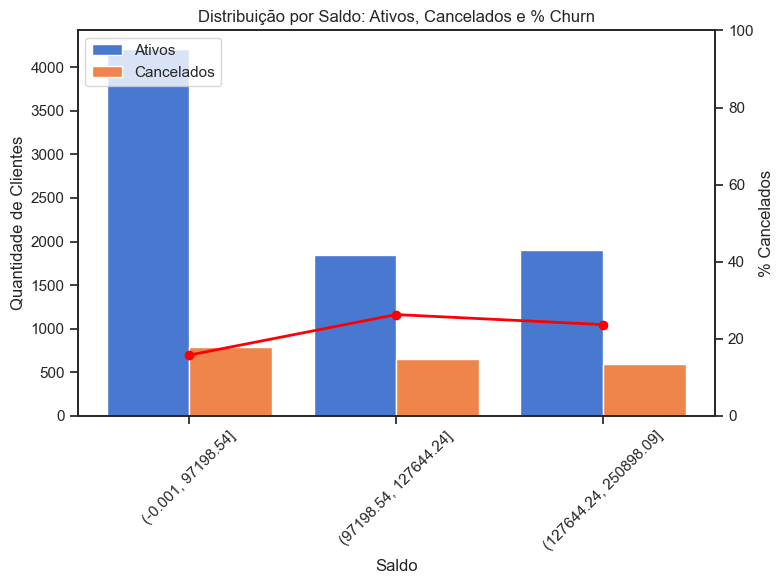

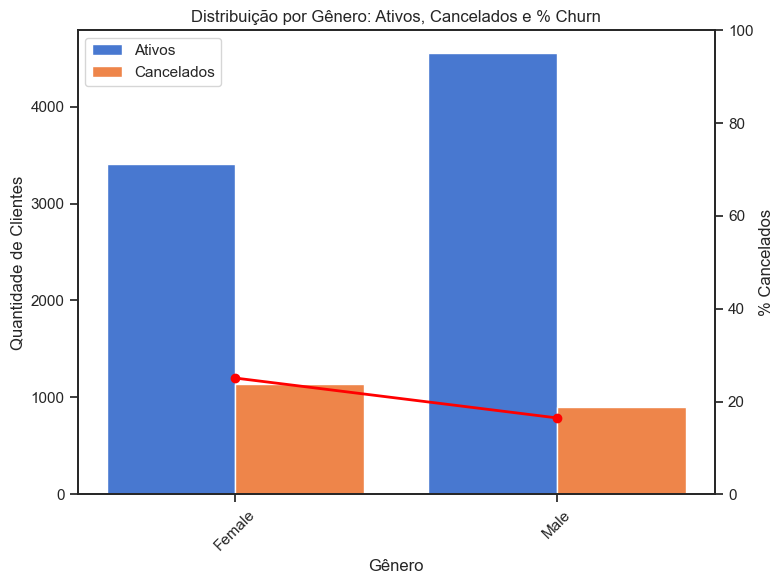

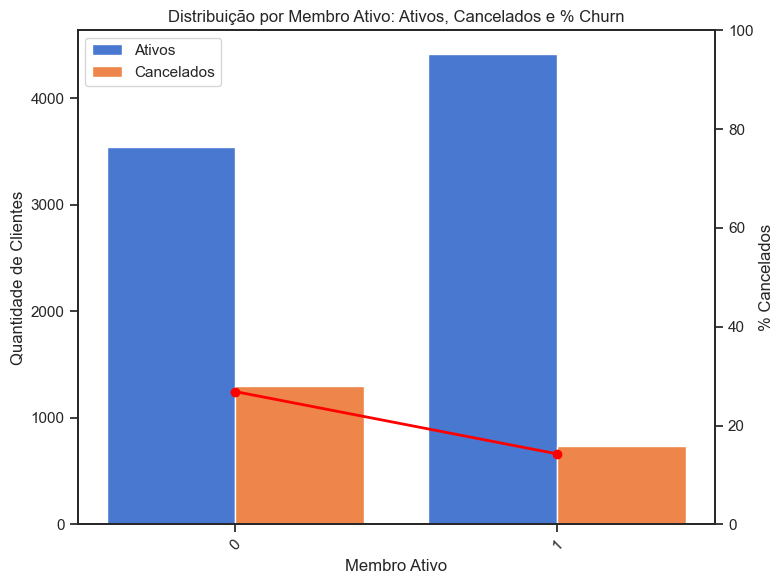

In [20]:
# Reverter Encoder
for col in ['Geography', 'Gender', 'CardType']:
    df[col] = encoders[col].inverse_transform(df[col])

# Gráficos
plot_churn_distribution(df, 'NumOfProducts', xlabel='Número de Produtos')
plot_churn_distribution(df, 'Age_bin',        xlabel='Idade')
plot_churn_distribution(df, 'Geography',      xlabel='Geografia')
plot_churn_distribution(df, 'Balance_bin',    xlabel='Saldo')
plot_churn_distribution(df, 'Gender',         xlabel='Gênero')
plot_churn_distribution(df, 'IsActiveMember',         xlabel='Membro Ativo')

## 9. Análise de Outliers (IQR)

In [21]:
def calcular_outliers_iqr(df, coluna):
    q1  = df[coluna].quantile(0.25)
    q3  = df[coluna].quantile(0.75)
    iqr = q3 - q1
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    outliers = df[(df[coluna] < lim_inf) | (df[coluna] > lim_sup)]

    print(f'\nColuna: {coluna}')
    print(f'Q1: {q1:.2f} | Q3: {q3:.2f} | IQR: {iqr:.2f}')
    print(f'Limite inferior: {lim_inf:.2f} | Limite superior: {lim_sup:.2f}')
    print(f'Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)')

    return outliers


Coluna: Age
Q1: 32.00 | Q3: 44.00 | IQR: 12.00
Limite inferior: 14.00 | Limite superior: 62.00
Outliers: 359 (3.59%)


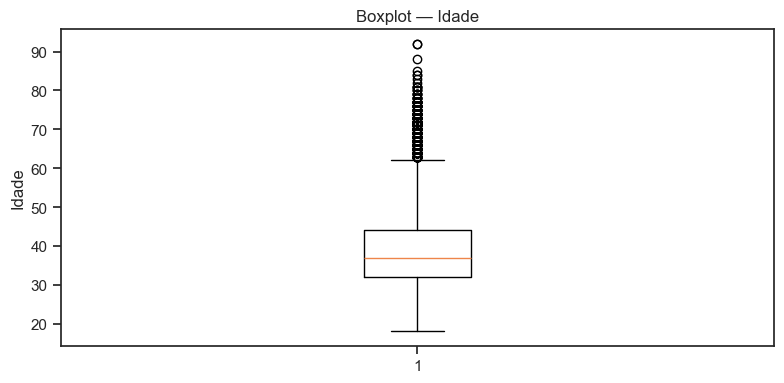


Coluna: Balance
Q1: 0.00 | Q3: 127644.24 | IQR: 127644.24
Limite inferior: -191466.36 | Limite superior: 319110.60
Outliers: 0 (0.00%)


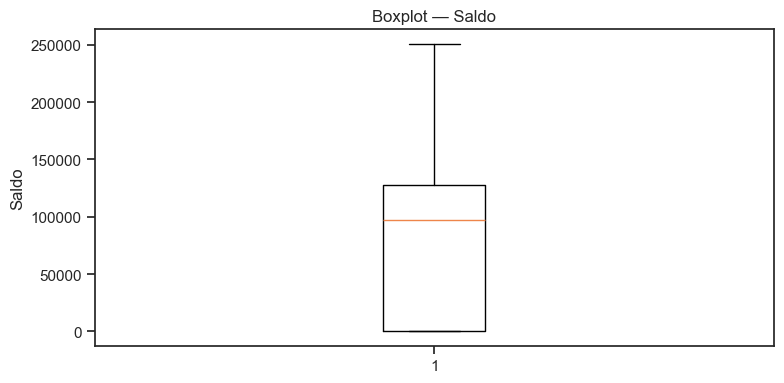

In [22]:
for col, titulo in [('Age', 'Idade'), ('Balance', 'Saldo')]:
    outliers = calcular_outliers_iqr(df, col)

    plt.figure(figsize=(8, 4))
    plt.boxplot(df[col])
    plt.title(f'Boxplot — {titulo}')
    plt.ylabel(titulo)
    plt.tight_layout()
    plt.show()

# 10. Análises

## 1. Quem são os clientes que mais cancelam?

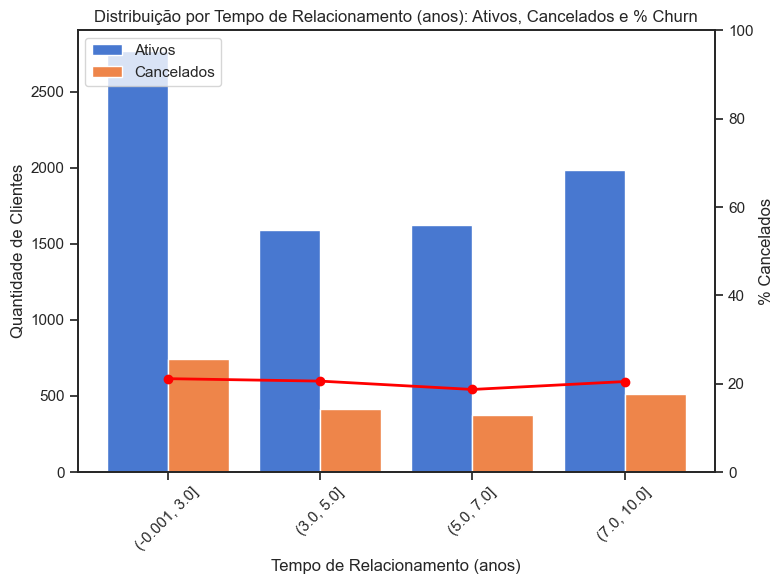

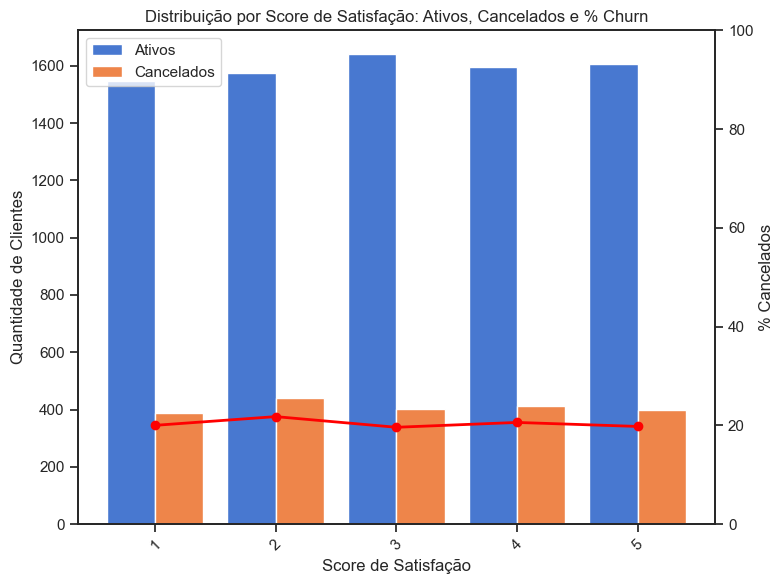

In [23]:
# ─────────────────────────────────────────────────────────────────────────────
# 1.1 PERFIL DEMOGRÁFICO — (idade, sexo, localização)
# ─────────────────────────────────────────────────────────────────────────────

plot_churn_distribution(df, 'Tenure_bin',        xlabel='Tempo de Relacionamento (anos)')
plot_churn_distribution(df, 'SatisfactionScore',  xlabel='Score de Satisfação')


=== 1.2 — Comparativo Financeiro: Churners vs. Não-Churners ===



,Métrica,Churners,Não-Churners,Diferença (%)
0,Credit Score Médio,645.41,651.84,-1.0%
1,Saldo Médio,91109.48,72742.75,25.2%
2,Salário Est. Médio,101509.91,99726.85,1.8%
3,Pontos Médios,604.45,607.04,-0.4%


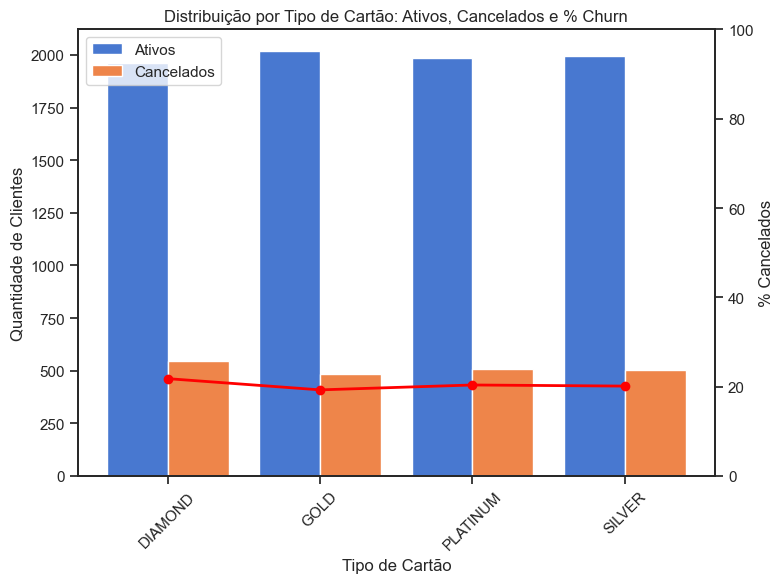

In [24]:
# ─────────────────────────────────────────────────────────────────────────────
# 1.2 HÁBITOS FINANCEIROS — (saldo médio, crédito utilizado, produtos contratados)
# ─────────────────────────────────────────────────────────────────────────────

churners     = df[df[TARGET] == 1]
nao_churners = df[df[TARGET] == 0]

print("\n=== 1.2 — Comparativo Financeiro: Churners vs. Não-Churners ===\n")
fin_cols = {
    'CreditScore':     'Credit Score Médio',
    'Balance':         'Saldo Médio',
    'EstimatedSalary': 'Salário Est. Médio',
    'PointEarned':     'Pontos Médios',
}
rows = []
for col, label in fin_cols.items():
    rows.append({
        'Métrica':        label,
        'Churners':       round(churners[col].mean(), 2),
        'Não-Churners':   round(nao_churners[col].mean(), 2),
        'Diferença (%)':  f"{((churners[col].mean() / nao_churners[col].mean()) - 1) * 100:.1f}%"
    })
display(pd.DataFrame(rows))

# Churn por tipo de cartão (não coberto no notebook)
plot_churn_distribution(df, 'CardType', xlabel='Tipo de Cartão')


In [25]:
# ─────────────────────────────────────────────────────────────────────────────
# 1.3 NÍVEL DE ENGAJAMENTO - (número de produtos, tempo de relacionamento)
# ─────────────────────────────────────────────────────────────────────────────

print("\n=== 1.3 — Taxa de Churn: Atividade × Nº de Produtos ===\n")
cross_eng = (
    df.groupby(['IsActiveMember', 'NumOfProducts'])[TARGET]
      .mean()
      .mul(100)
      .round(1)
      .unstack()
      .rename(index={0: 'Inativo', 1: 'Ativo'})
)
cross_eng.columns = [f'{c} produto(s)' for c in cross_eng.columns]
display(cross_eng)


=== 1.3 — Taxa de Churn: Atividade × Nº de Produtos ===



,1 produto(s),2 produto(s),3 produto(s),4 produto(s)
IsActiveMember,,,,
Inativo,36.7,9.9,88.2,100.0
Ativo,18.9,5.6,75.2,100.0


## 2. Quais variáveis melhor explicam o churn?


=== 2.2 — Information Value (IV) com classificação de poder preditivo ===

  IV > 0.5  = Suspeitamente forte (checar)
  0.3-0.5   = Forte
  0.1-0.3   = Médio
  0.02-0.1  = Fraco
  < 0.02    = Inútil



,IV,Classificação
Complain,12.8685,⚠ Muito forte (revisar)
NumOfProducts,0.9689,⚠ Muito forte (revisar)
Age,0.7490,⚠ Muito forte (revisar)
Geography,0.1680,🔵 Médio
IsActiveMember,0.1536,🔵 Médio
Balance,0.0841,🟡 Fraco
Gender,0.0694,🟡 Fraco
CreditScore,0.0072,❌ Inútil
PointEarned,0.0059,❌ Inútil
CardType,0.0031,❌ Inútil


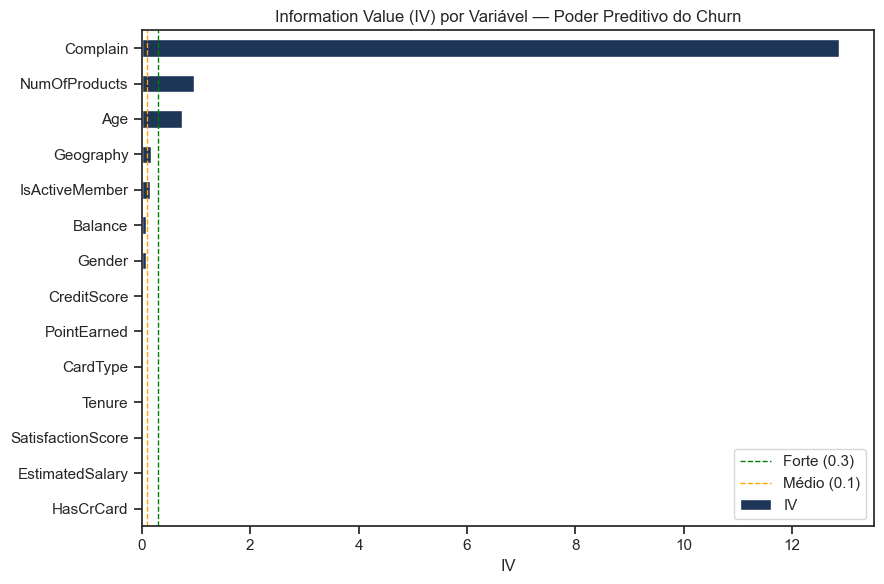

In [26]:
# ─────────────────────────────────────────────────────────────────────────────
# 2.1. Quais características são mais relevantes para prever o cancelamento?
# 2.2. Qual o valor da informação de cada variável para tomada de decisão?
# ─────────────────────────────────────────────────────────────────────────────

print("\n=== 2.2 — Information Value (IV) com classificação de poder preditivo ===\n")
print("  IV > 0.5  = Suspeitamente forte (checar)")
print("  0.3-0.5   = Forte")
print("  0.1-0.3   = Médio")
print("  0.02-0.1  = Fraco")
print("  < 0.02    = Inútil\n")

def classificar_iv(v):
    if v > 0.5:  return "⚠ Muito forte (revisar)"
    if v > 0.3:  return "✅ Forte"
    if v > 0.1:  return "🔵 Médio"
    if v > 0.02: return "🟡 Fraco"
    return "❌ Inútil"

iv_classificado = iv_df.copy()
iv_classificado['Classificação'] = iv_classificado['IV'].apply(classificar_iv)
display(iv_classificado)

# Gráfico de barras do IV (aproveitando iv_df já existente)
iv_df.sort_values('IV').plot(
    kind='barh', figsize=(9, 6), legend=False, color='#1D3557', edgecolor='white'
)
plt.axvline(0.3, color='green',  linestyle='--', linewidth=1, label='Forte (0.3)')
plt.axvline(0.1, color='orange', linestyle='--', linewidth=1, label='Médio (0.1)')
plt.title('Information Value (IV) por Variável — Poder Preditivo do Churn')
plt.xlabel('IV')
plt.legend()
plt.tight_layout()
plt.show()


In [27]:
# 2.2. Qual o valor da informação de cada variável para tomada de decisão?


## 3. Existem padrões de cancelamento que indicam problemas internos?



=== 3.1 — Churn por Faixa de Credit Score ===

CreditScore_bin
(349.999, 566.0]    22.5
(566.0, 627.0]      20.8
(627.0, 678.0]      19.7
(678.0, 735.0]      18.3
(735.0, 850.0]      20.6

Correlação Pearson (CreditScore × Churn): -0.0268
→ Correlação próxima de 0 indica que crédito alto NÃO protege contra cancelamento.



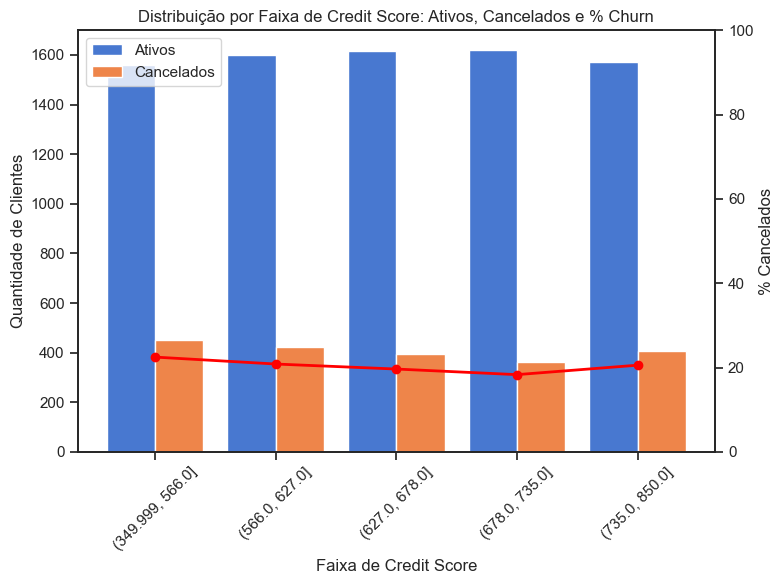

In [28]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.1 — CLIENTES COM CRÉDITO ALTO ESTÃO SAINDO?
# ─────────────────────────────────────────────────────────────────────────────

print("\n=== 3.1 — Churn por Faixa de Credit Score ===\n")

churn_credit = df.groupby('CreditScore_bin', observed=True)[TARGET].mean() * 100
print(churn_credit.round(1).to_string())

corr_credit = df['CreditScore'].corr(df[TARGET])
print(f"\nCorrelação Pearson (CreditScore × Churn): {corr_credit:.4f}")
print("→ Correlação próxima de 0 indica que crédito alto NÃO protege contra cancelamento.\n")

plot_churn_distribution(df, 'CreditScore_bin', xlabel='Faixa de Credit Score')


In [29]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.2 — CLIENTES COM MUITOS PRODUTOS TAMBÉM CANCELAM?
# ─────────────────────────────────────────────────────────────────────────────

print("\n=== 3.2 — Churn por Nº de Produtos (volume absoluto + taxa) ===\n")

prod_detail = (
    df.groupby('NumOfProducts')[TARGET]
      .agg(Total='count', Churners='sum')
      .assign(Retidos=lambda x: x['Total'] - x['Churners'],
              Taxa_Churn=lambda x: (x['Churners'] / x['Total'] * 100).round(1))
)
display(prod_detail)
print("→ Padrão U-invertido: quem tem 3+ produtos cancela muito mais.")


=== 3.2 — Churn por Nº de Produtos (volume absoluto + taxa) ===



,Total,Churners,Retidos,Taxa_Churn
NumOfProducts,,,,
1,5084,1409,3675,27.7
2,4590,349,4241,7.6
3,266,220,46,82.7
4,60,60,0,100.0


→ Padrão U-invertido: quem tem 3+ produtos cancela muito mais.



=== 3.3 — Churn por Reclamação ===



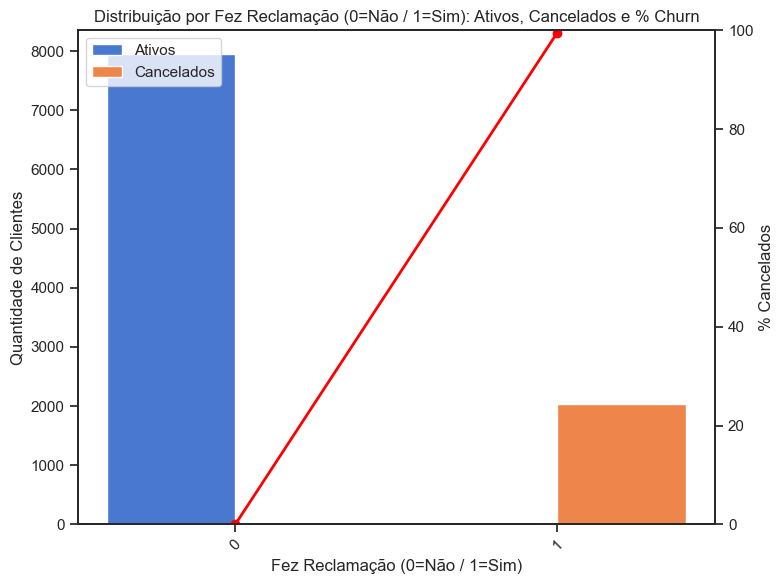


Taxa de Churn: Reclamação × Score de Satisfação (%)



,Satisfação 1,Satisfação 2,Satisfação 3,Satisfação 4,Satisfação 5
Complain,,,,,
Sem Reclamação,0.1,0.1,0.0,0.1,0.0
Com Reclamação,99.7,99.8,98.8,100.0,99.2


→ Reclamação domina o churn independentemente do score de satisfação.


In [30]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.3 — RECLAMAÇÕES E CANAIS DE ATENDIMENTO
# ─────────────────────────────────────────────────────────────────────────────

print("\n=== 3.3 — Churn por Reclamação ===\n")

plot_churn_distribution(df, 'Complain', xlabel='Fez Reclamação (0=Não / 1=Sim)')

# Tabela cruzada: Reclamação × Satisfação → taxa de churn
print("\nTaxa de Churn: Reclamação × Score de Satisfação (%)\n")
cross_rec_sat = (
    df.groupby(['Complain', 'SatisfactionScore'])[TARGET]
      .mean()
      .mul(100)
      .round(1)
      .unstack()
      .rename(index={0: 'Sem Reclamação', 1: 'Com Reclamação'})
)
cross_rec_sat.columns = [f'Satisfação {c}' for c in cross_rec_sat.columns]
display(cross_rec_sat)
print("→ Reclamação domina o churn independentemente do score de satisfação.")

## 4. Que decisões estratégicas podem ser tomadas com base nos dados?


=== 4.1 — Segmentos de Risco para Pacotes de Retenção ===



,Total,Churners,Saldo_Medio,Taxa_Churn
RiskScore,,,,
0,1248,0,21377.9,0.0
1,3441,58,57446.3,1.7
2,3053,366,96087.7,12.0
3,1522,879,102847.2,57.8
4,661,660,122374.3,99.8
5,75,75,129705.4,100.0


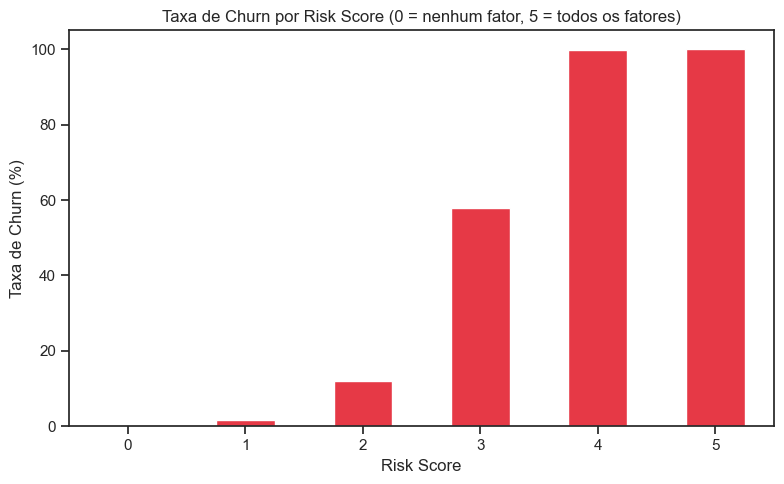

In [31]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.1 — SEGMENTOS DE RISCO PARA PACOTES DE RETENÇÃO
# ─────────────────────────────────────────────────────────────────────────────

print("\n=== 4.1 — Segmentos de Risco para Pacotes de Retenção ===\n")

# Risk score composto com fatores já identificados pelo IV no bloco 5
df['RiskScore'] = (
    (df['Age']           > df['Age'].median()).astype(int) +      # idade acima da mediana
    (df['IsActiveMember'] == 0).astype(int) +                     # inativo
    (df['NumOfProducts']  >= 3).astype(int) +                     # 3+ produtos
    (df['Complain']       == 1).astype(int) +                     # fez reclamação
    (df['Balance']        > df['Balance'].median()).astype(int)    # saldo acima da mediana
)

seg = (
    df.groupby('RiskScore')
      .agg(
          Total       = (TARGET, 'count'),
          Churners    = (TARGET, 'sum'),
          Saldo_Medio = ('Balance', 'mean')
      )
      .assign(Taxa_Churn=lambda x: (x['Churners'] / x['Total'] * 100).round(1))
)
display(seg.round(1))

seg['Taxa_Churn'].plot(
    kind='bar', figsize=(8, 5), color='#E63946', edgecolor='white', rot=0
)
plt.title('Taxa de Churn por Risk Score (0 = nenhum fator, 5 = todos os fatores)')
plt.xlabel('Risk Score')
plt.ylabel('Taxa de Churn (%)')
plt.tight_layout()
plt.show()


=== 4.2 — Clientes de Alta Receita com Alto Risco de Churn ===

Clientes com RiskScore ≥ 3 e receita acima da mediana: 1,706
Receita média estimada em risco por cliente: R$ 3,163.48
Taxa de churn real neste grupo: 65.5%



,Age,Balance,EstimatedSalary,NumOfProducts,IsActiveMember,Complain,RiskScore,Receita_Estimada,Exited
0,57,238387.56,147964.99,1,1,1,3,5507.58,1
1,38,250898.09,81054.00,3,1,1,4,5423.23,1
2,40,221532.80,171867.08,1,0,0,3,5289.99,0
3,35,211774.31,188574.12,1,0,1,3,5178.36,1
4,40,203715.15,179978.68,1,0,1,4,4974.20,1
5,42,222267.63,101108.85,1,0,1,4,4950.90,1
6,56,209767.31,150694.42,2,1,1,3,4948.82,1
7,39,207034.96,157694.76,2,0,1,4,4929.17,1
8,47,198546.10,191198.92,2,0,1,4,4926.92,1
9,43,212696.32,115268.86,1,0,0,3,4830.27,0


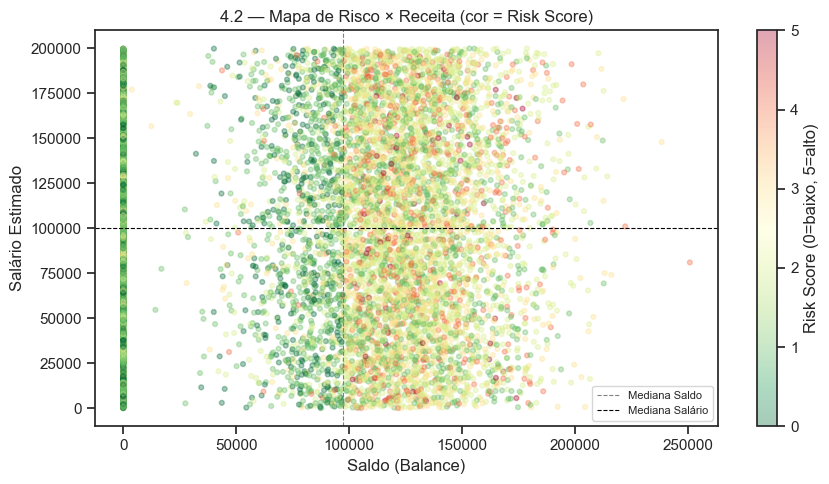

In [32]:
# ─────────────────────────────────────────────────────────────────────────────
# 4.2 — CLIENTES COM ALTA RECEITA E ALTO RISCO
# ─────────────────────────────────────────────────────────────────────────────

print("\n=== 4.2 — Clientes de Alta Receita com Alto Risco de Churn ===\n")

# Receita estimada simples: saldo * taxa + salário * taxa de cross-sell
df['Receita_Estimada'] = df['Balance'] * 0.02 + df['EstimatedSalary'] * 0.005

med_receita = df['Receita_Estimada'].median()
alto_risco  = df[(df['RiskScore'] >= 3) & (df['Receita_Estimada'] > med_receita)].copy()

print(f"Clientes com RiskScore ≥ 3 e receita acima da mediana: {len(alto_risco):,}")
print(f"Receita média estimada em risco por cliente: R$ {alto_risco['Receita_Estimada'].mean():,.2f}")
print(f"Taxa de churn real neste grupo: {alto_risco[TARGET].mean()*100:.1f}%\n")

# Top 10 prioritários para ação de retenção
cols_view = ['Age', 'Balance', 'EstimatedSalary', 'NumOfProducts',
             'IsActiveMember', 'Complain', 'RiskScore', 'Receita_Estimada', TARGET]
display(
    alto_risco[cols_view]
    .sort_values('Receita_Estimada', ascending=False)
    .head(10)
    .round(2)
    .reset_index(drop=True)
)

# Scatter: Saldo × Receita Estimada colorido por churn
plt.figure(figsize=(9, 5))
scatter = plt.scatter(
    df['Balance'],
    df['EstimatedSalary'],
    c=df['RiskScore'],
    cmap='RdYlGn_r',
    alpha=0.35, s=12
)
plt.colorbar(scatter, label='Risk Score (0=baixo, 5=alto)')
plt.axvline(df['Balance'].median(),          color='gray', linestyle='--', linewidth=0.8, label='Mediana Saldo')
plt.axhline(df['EstimatedSalary'].median(),  color='black', linestyle='--', linewidth=0.8, label='Mediana Salário')
plt.title('4.2 — Mapa de Risco × Receita (cor = Risk Score)')
plt.xlabel('Saldo (Balance)')
plt.ylabel('Salário Estimado')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [33]:
# ─────────────────────────────────────────────────────────────────────────────
# RESUMO EXECUTIVO FINAL
# ─────────────────────────────────────────────────────────────────────────────

taxa_global = df[TARGET].mean() * 100
top_iv      = iv_df.head(3).index.tolist()

print("\n" + "="*65)
print("  RESUMO EXECUTIVO — ANÁLISE DE CHURN")
print("="*65)
print(f"""
  Taxa global de churn: {taxa_global:.1f}%

  QUEM CANCELA MAIS (1.1–1.3):
  • Mulheres cancelam mais que homens
  • Clientes acima da meia-idade (maiores taxas: 40–60 anos)
  • Alemanha lidera o churn por país
  • Membros inativos (IsActiveMember=0) têm risco até 2× maior
  • Clientes com 3 ou 4 produtos cancelam em proporção muito alta

  O QUE MELHOR EXPLICA O CHURN (2.1–2.2):
  • Top variáveis por IV: {", ".join(top_iv)}
  • Reclamação (Complain) é a variável de maior IV isolada
  • Age e Balance têm poder preditivo médio-forte
  • CreditScore e SatisfactionScore têm IV baixo (não discriminam bem)

  PADRÕES INTERNOS (3.1–3.3):
  • Crédito alto NÃO retém o cliente — correlação ≈ 0
  • 3+ produtos → churn acima de 80% em alguns segmentos
  • Reclamação domina: com reclamação o churn ultrapassa 99%,
    independentemente do score de satisfação informado

  AÇÕES ESTRATÉGICAS (4.1–4.2):
  • Foco imediato: clientes com RiskScore ≥ 3 (3+ fatores de risco)
  • Prioridade financeira: {len(alto_risco):,} clientes com alta receita +
    alto risco identificados para campanha de retenção personalizada
  • Alavanca mais rápida: resolução de reclamações antes do cancelamento
  • Revisar proposta para clientes com muitos produtos (complexidade → evasão)
""")


  RESUMO EXECUTIVO — ANÁLISE DE CHURN

  Taxa global de churn: 20.4%

  QUEM CANCELA MAIS (1.1–1.3):
  • Mulheres cancelam mais que homens
  • Clientes acima da meia-idade (maiores taxas: 40–60 anos)
  • Alemanha lidera o churn por país
  • Membros inativos (IsActiveMember=0) têm risco até 2× maior
  • Clientes com 3 ou 4 produtos cancelam em proporção muito alta

  O QUE MELHOR EXPLICA O CHURN (2.1–2.2):
  • Top variáveis por IV: Complain, NumOfProducts, Age
  • Reclamação (Complain) é a variável de maior IV isolada
  • Age e Balance têm poder preditivo médio-forte
  • CreditScore e SatisfactionScore têm IV baixo (não discriminam bem)

  PADRÕES INTERNOS (3.1–3.3):
  • Crédito alto NÃO retém o cliente — correlação ≈ 0
  • 3+ produtos → churn acima de 80% em alguns segmentos
  • Reclamação domina: com reclamação o churn ultrapassa 99%,
    independentemente do score de satisfação informado

  AÇÕES ESTRATÉGICAS (4.1–4.2):
  • Foco imediato: clientes com RiskScore ≥ 3 (3+ fatores de ri